# 🧠 Comprehensive Model Evaluation

This notebook evaluates all trained classification models on the test dataset and visualizes training curves.

**Models Evaluated:**
- ConvNeXt Base
- ResNet152V2
- DenseNet201
- EfficientNetV2S
- VGG16

**Outputs:**
1. Training curves for all models
2. Test set performance metrics (Accuracy, Precision, Recall, F1)
3. Confusion matrices
4. Updated README with results

## 1. Setup

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tqdm.notebook import tqdm

from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich import print as rprint

from src.classification.data import build_dataframe, make_dataset
from src.classification.inference import ClassificationEvaluator

# Initialize Rich Console
console = Console()

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

console.print(f"[bold green]TensorFlow version:[/bold green] {tf.__version__}")
console.print(f"[bold green]Project root:[/bold green] {PROJECT_ROOT}")

TensorFlow version: 2.20.0

Project root: c:\Users\USER\Desktop\AI-Assisted-Brain-Tumor-Localization-and-Classification-in-Medical-Imaging

## 2. Load Training Logs

In [2]:
# Define models and their log files
models_info = {
    'ConvNeXt': {
        'weights': 'weights/classification/ConvNeXtBase_best_weights.keras',
        'log': 'logs/classification/ConvNeXtBase_training_log.csv',
        'model_name': 'ConvNeXtBase'
    },
    'ResNet152V2': {
        'weights': 'weights/classification/ResNet152V2_best_weights.keras',
        'log': 'logs/classification/ResNet152V2_training_log.csv',
        'model_name': 'ResNet152V2'
    },
    'DenseNet201': {
        'weights': 'weights/classification/DenseNet201_best_weights.keras',
        'log': 'logs/classification/DenseNet201_training_log.csv',
        'model_name': 'DenseNet201'
    },
    'EfficientNetV2S': {
        'weights': 'weights/classification/EfficientNetV2S_best_weights.keras',
        'log': 'logs/classification/EfficientNetV2S_training_log.csv',
        'model_name': 'EfficientNetV2S'
    },
    'VGG16': {
        'weights': 'weights/classification/VGG16_best_weights.keras',
        'log': 'logs/classification/VGG16_training_log.csv',
        'model_name': 'VGG16'
    }
}

# Load training logs with progress bar
console.print("\n[bold cyan]📂 Loading Training Logs[/bold cyan]")
training_logs = {}

for name, info in tqdm(models_info.items(), desc="Loading logs", unit="model"):
    log_path = PROJECT_ROOT / info['log']
    if log_path.exists():
        training_logs[name] = pd.read_csv(log_path)
        console.print(f"  [green]✓[/green] {name}: [yellow]{len(training_logs[name])}[/yellow] epochs")
    else:
        console.print(f"  [red]✗[/red] Log file not found: {log_path}")

console.print(f"\n[bold green]Total models loaded:[/bold green] [yellow]{len(training_logs)}[/yellow]")

📂 Loading Training Logs

Loading logs:   0%|          | 0/5 [00:00<?, ?model/s]

✓ ConvNeXt: 115 epochs

✓ ResNet152V2: 85 epochs

✓ DenseNet201: 77 epochs

✓ EfficientNetV2S: 184 epochs

✓ VGG16: 92 epochs

Total models loaded: 5

## 3. Training Curves Visualization

### 3.1 Loss Curves

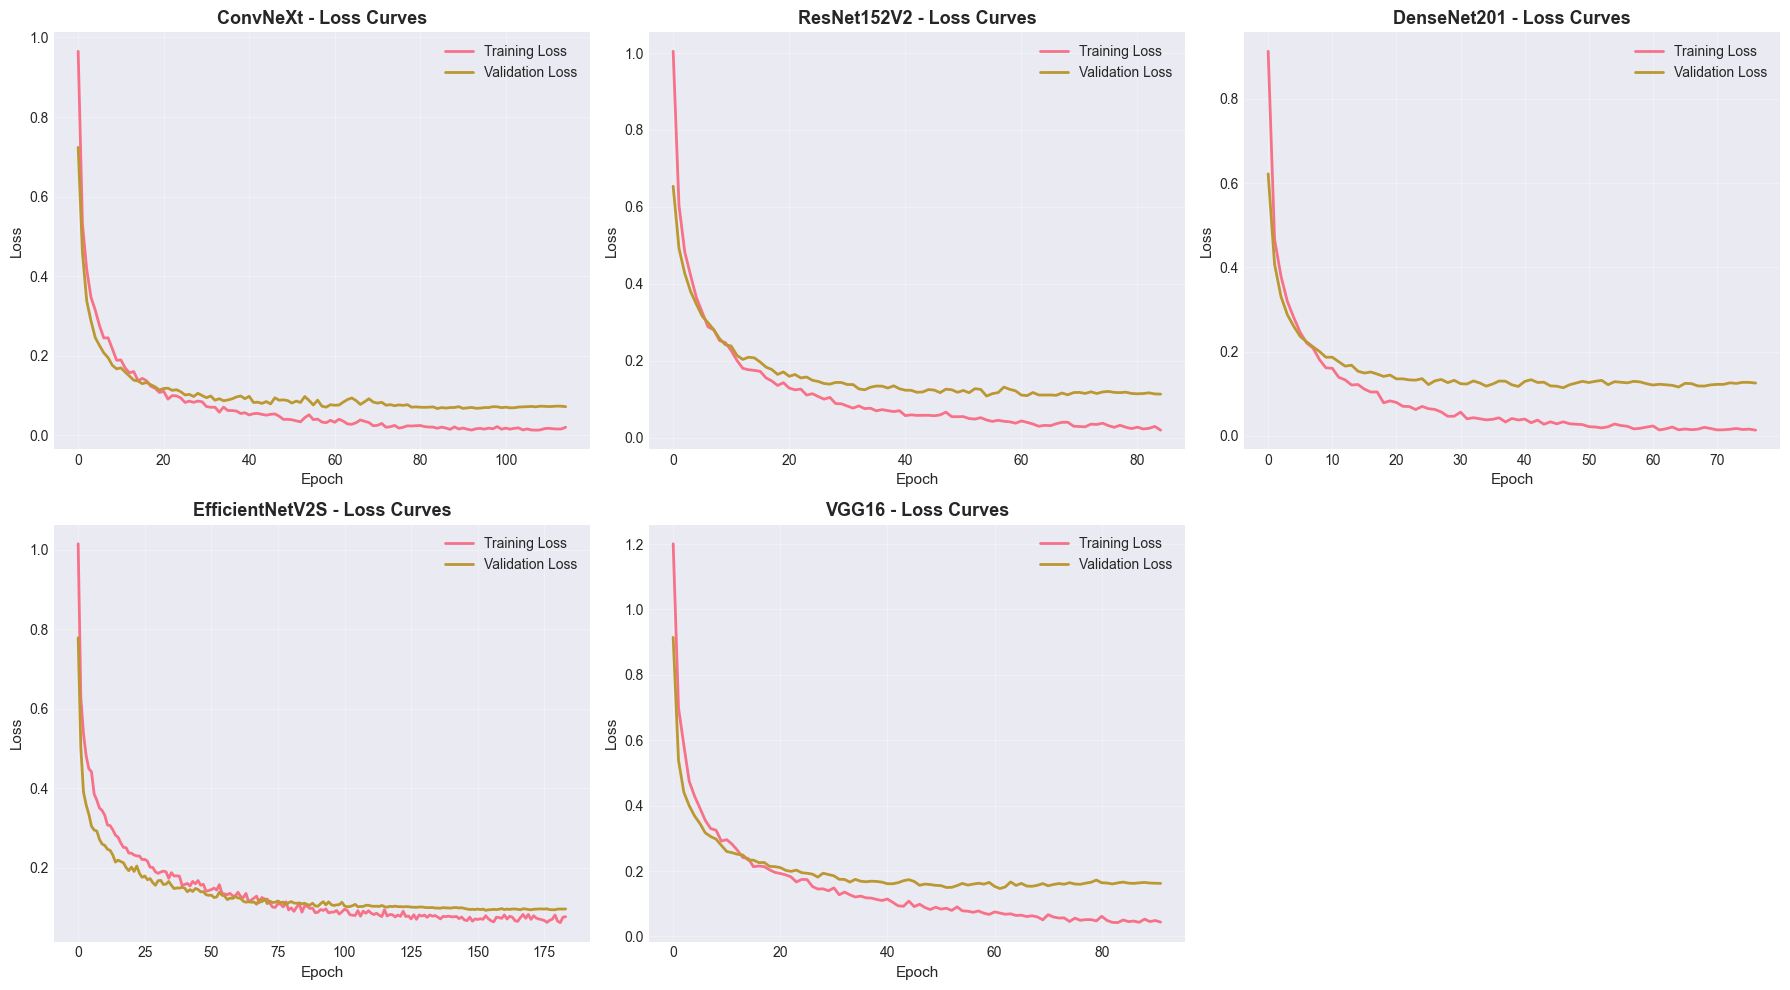

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, log) in enumerate(training_logs.items()):
    ax = axes[idx]
    ax.plot(log['epoch'], log['loss'], label='Training Loss', linewidth=2)
    ax.plot(log['epoch'], log['val_loss'], label='Validation Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(f'{name} - Loss Curves', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide the last subplot if there are fewer than 6 models
if len(training_logs) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'logs/classification/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Accuracy Curves

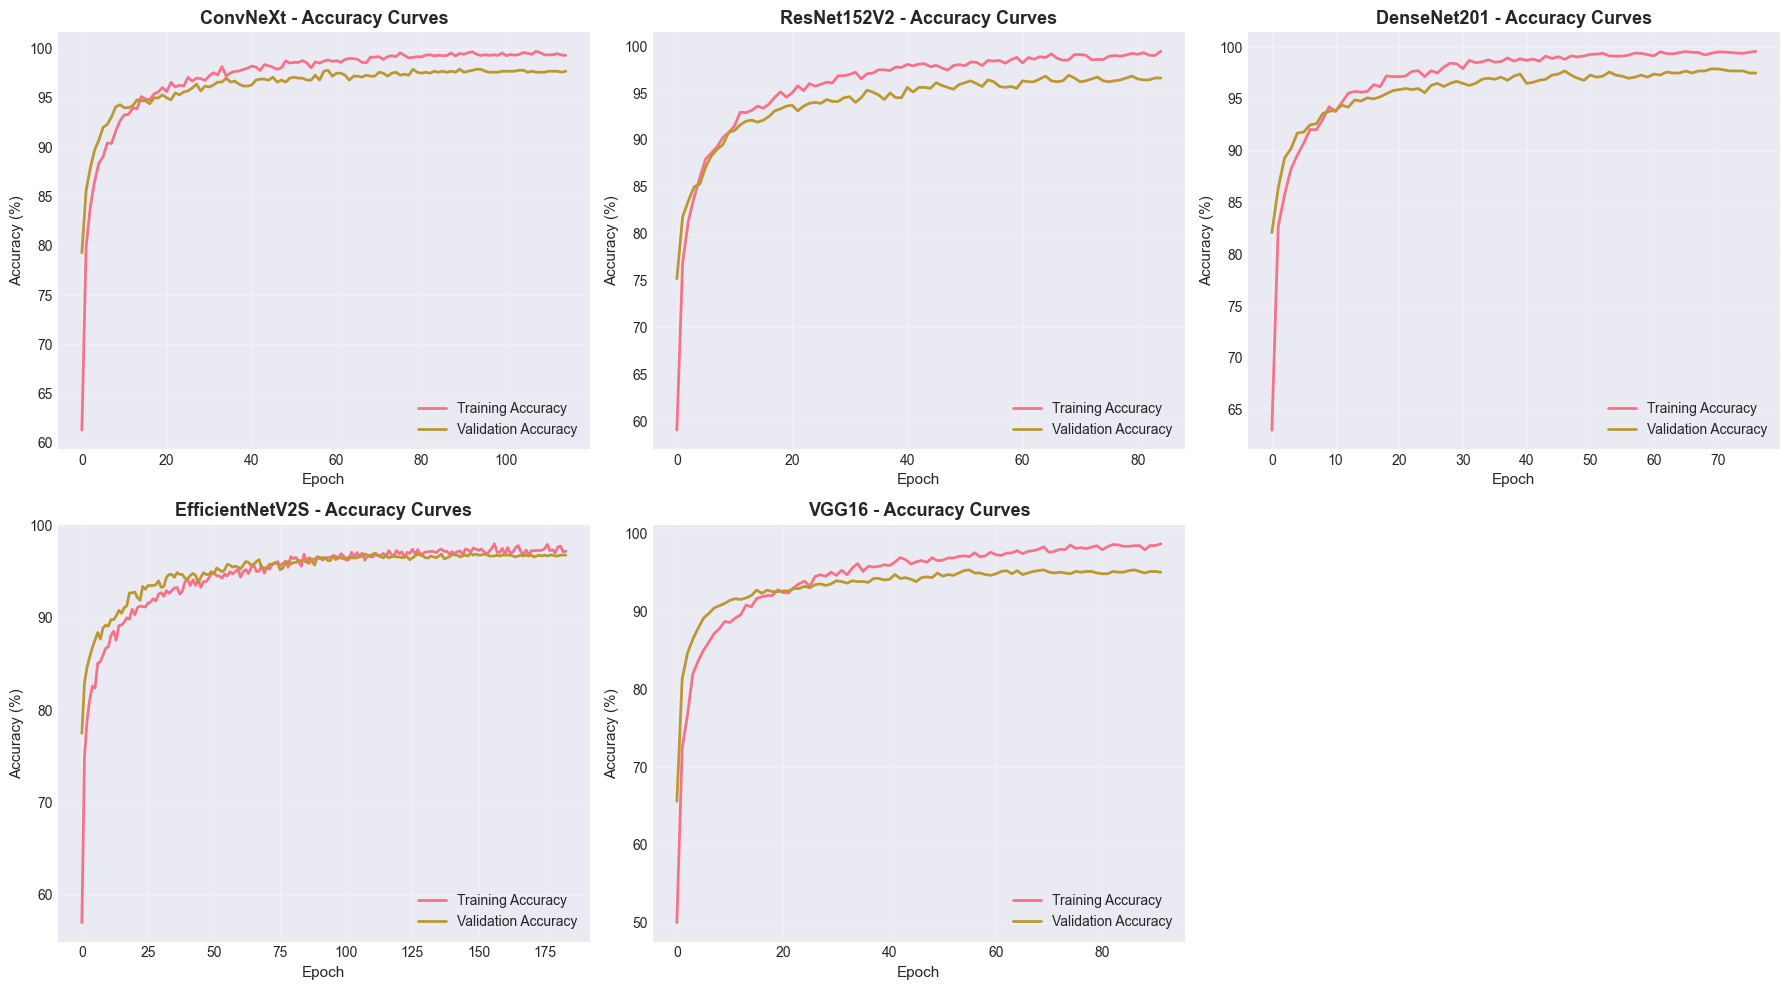

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, log) in enumerate(training_logs.items()):
    ax = axes[idx]
    ax.plot(log['epoch'], log['accuracy'] * 100, label='Training Accuracy', linewidth=2)
    ax.plot(log['epoch'], log['val_accuracy'] * 100, label='Validation Accuracy', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(f'{name} - Accuracy Curves', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

if len(training_logs) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'logs/classification/accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Recall Curves

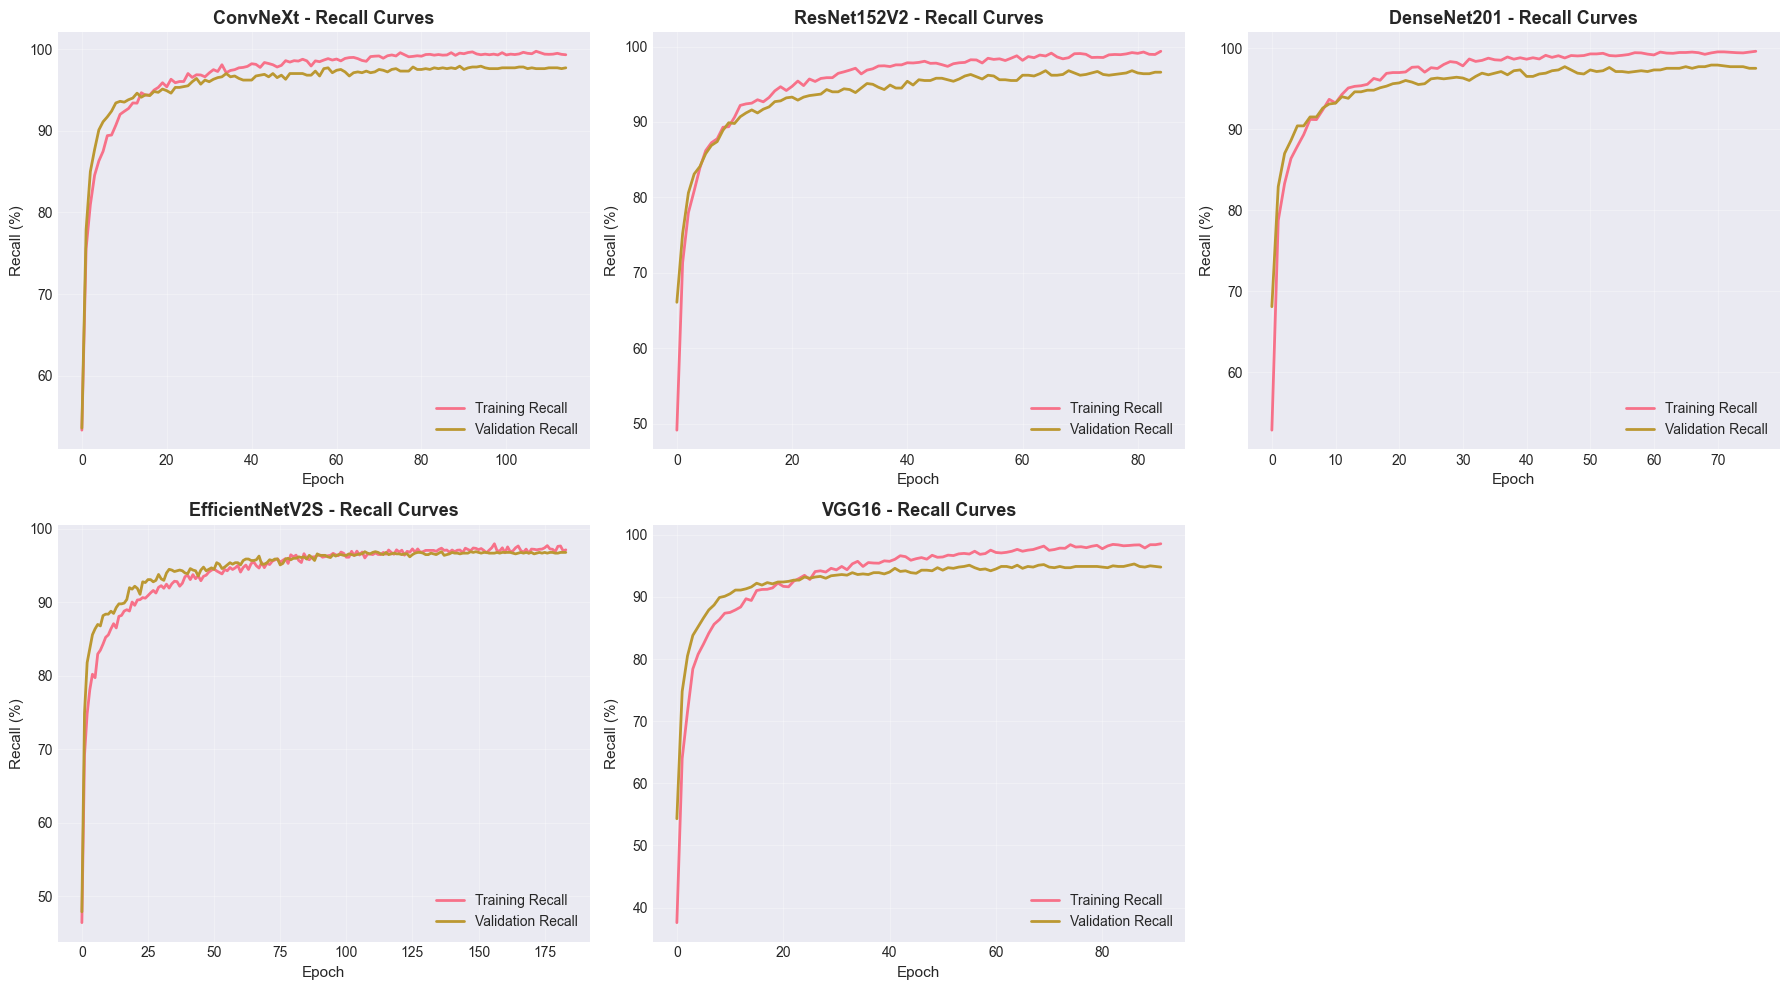

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, log) in enumerate(training_logs.items()):
    ax = axes[idx]
    ax.plot(log['epoch'], log['overall_recall'] * 100, label='Training Recall', linewidth=2)
    ax.plot(log['epoch'], log['val_overall_recall'] * 100, label='Validation Recall', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Recall (%)', fontsize=11)
    ax.set_title(f'{name} - Recall Curves', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

if len(training_logs) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'logs/classification/recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 AUC Curves

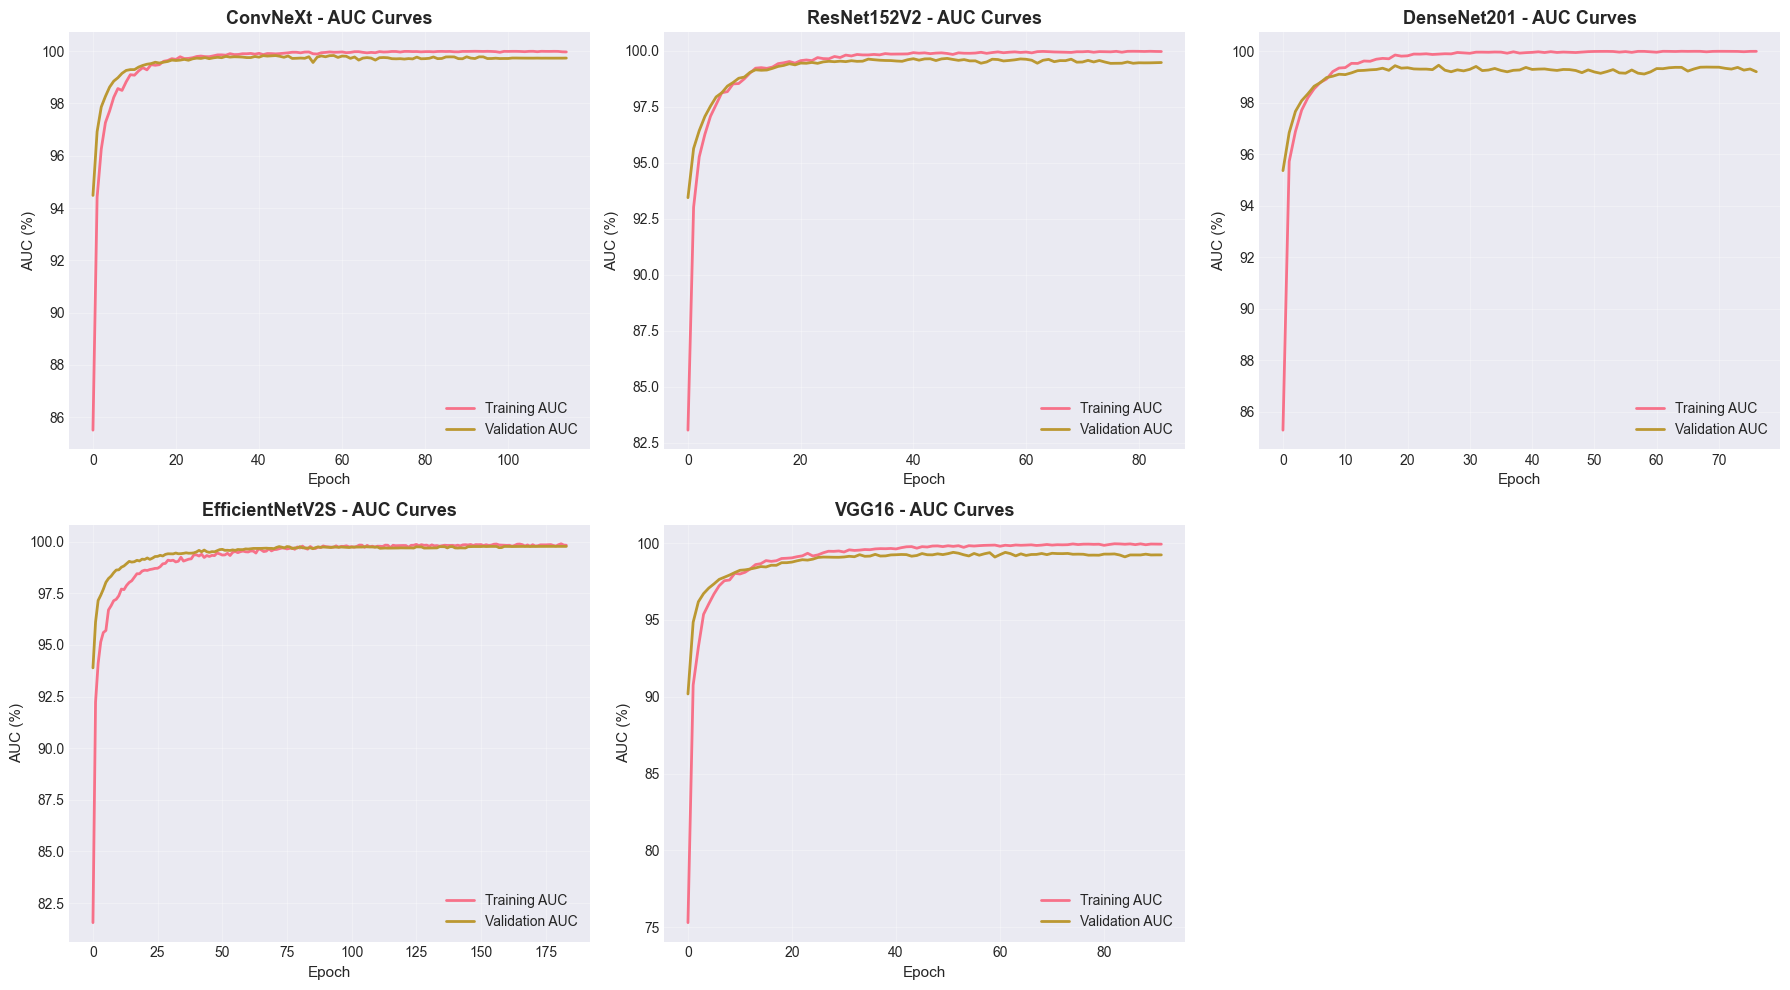

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, log) in enumerate(training_logs.items()):
    ax = axes[idx]
    ax.plot(log['epoch'], log['auc_ovr'] * 100, label='Training AUC', linewidth=2)
    ax.plot(log['epoch'], log['val_auc_ovr'] * 100, label='Validation AUC', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('AUC (%)', fontsize=11)
    ax.set_title(f'{name} - AUC Curves', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

if len(training_logs) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'logs/classification/auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Comparison - All Models

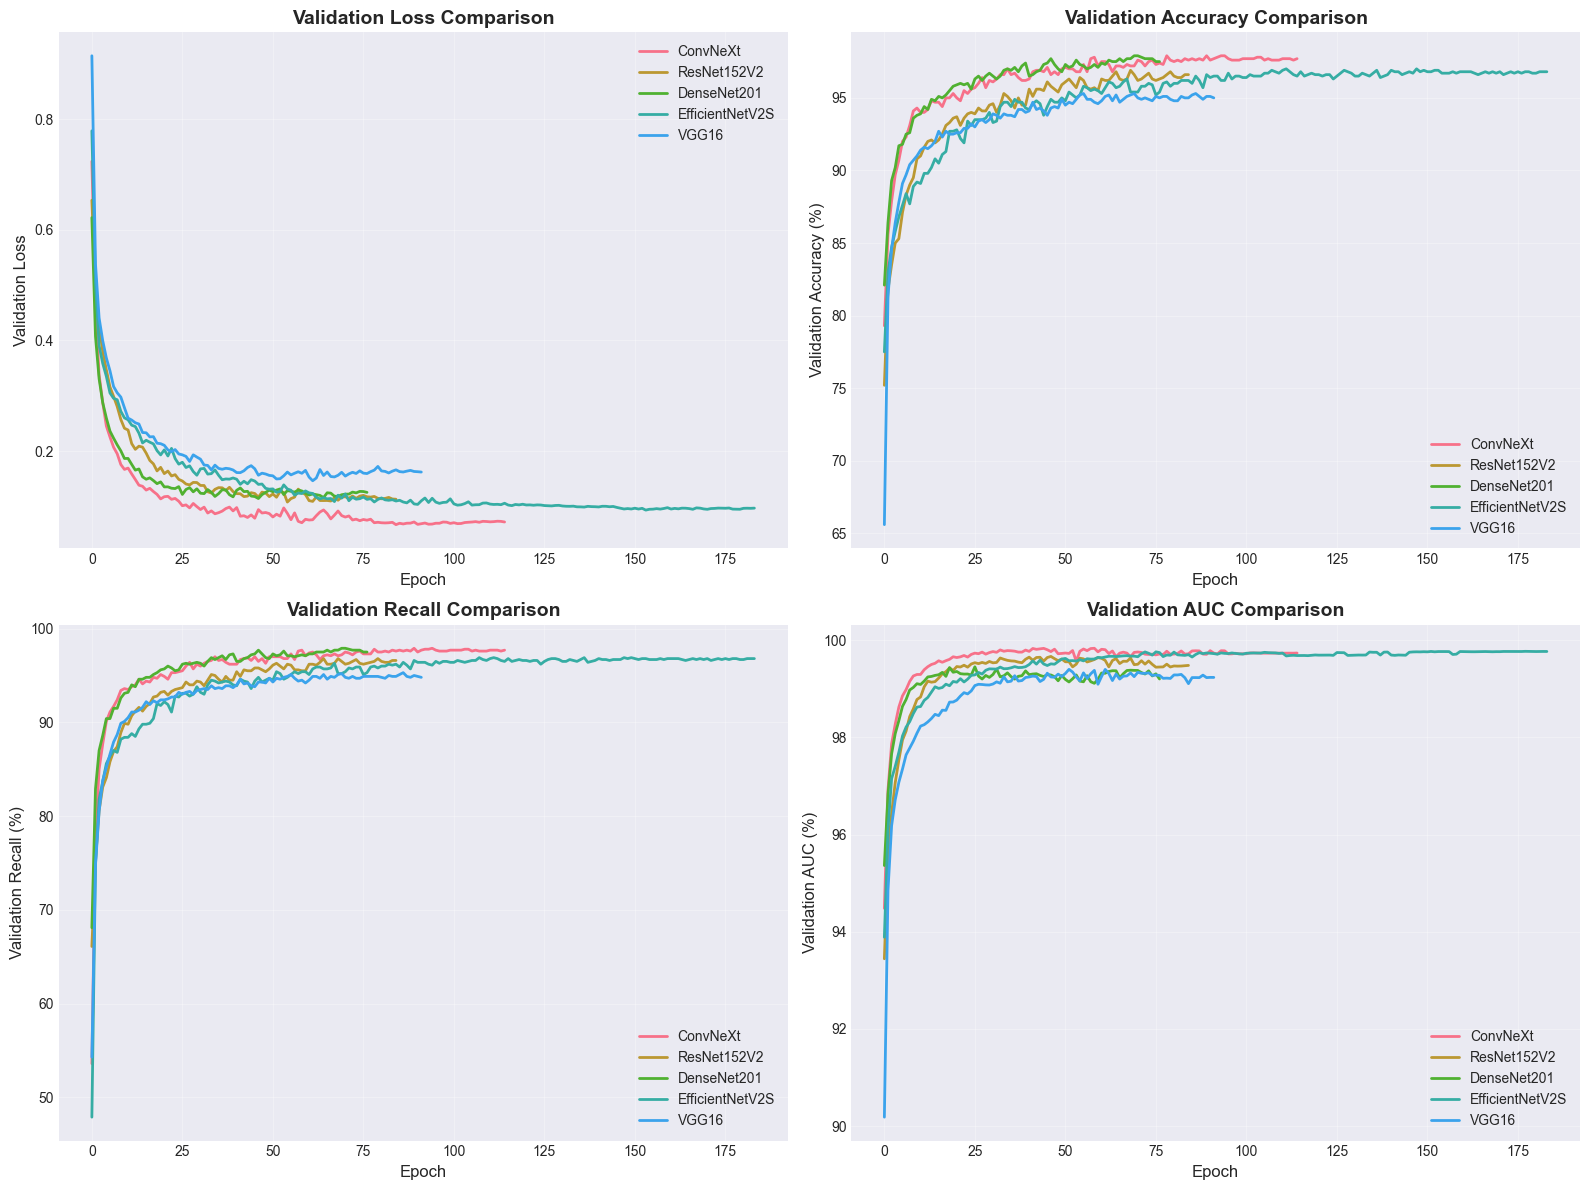

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Validation Loss
for name, log in training_logs.items():
    axes[0, 0].plot(log['epoch'], log['val_loss'], label=name, linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Validation Loss', fontsize=12)
axes[0, 0].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation Accuracy
for name, log in training_logs.items():
    axes[0, 1].plot(log['epoch'], log['val_accuracy'] * 100, label=name, linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[0, 1].set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Validation Recall
for name, log in training_logs.items():
    axes[1, 0].plot(log['epoch'], log['val_overall_recall'] * 100, label=name, linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Validation Recall (%)', fontsize=12)
axes[1, 0].set_title('Validation Recall Comparison', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Validation AUC
for name, log in training_logs.items():
    axes[1, 1].plot(log['epoch'], log['val_auc_ovr'] * 100, label=name, linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Validation AUC (%)', fontsize=12)
axes[1, 1].set_title('Validation AUC Comparison', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'logs/classification/all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Load Test Dataset

In [8]:
console.print("\n[bold cyan]📊 Loading Test Dataset[/bold cyan]")
test_df = build_dataframe(split="test")
console.print(f"[green]Total test samples:[/green] [yellow]{len(test_df)}[/yellow]")

# Create table for class distribution
table = Table(title="Class Distribution", show_header=True, header_style="bold magenta")
table.add_column("Class", style="cyan")
table.add_column("Count", justify="right", style="yellow")

for class_name, count in test_df['class'].value_counts().items():
    table.add_row(class_name, str(count))

console.print(table)

📊 Loading Test Dataset

Total test samples: 1000

  Class Distribution  
┏━━━━━━━━━━━━┳━━━━━━━┓
┃ Class      ┃ Count ┃
┡━━━━━━━━━━━━╇━━━━━━━┩
│ meningioma │   306 │
│ pituitary  │   300 │
│ glioma     │   254 │
│ no_tumor   │   140 │
└────────────┴───────┘

## 5. Evaluate Models on Test Set

Evaluating models:   0%|          | 0/5 [00:00<?, ?model/s]

╭────────────────────────╮
│ 🔍 Evaluating ConvNeXt │
╰────────────────────────╯

✓ Model loaded: ConvNeXtBase_best_weights.keras

32/32 ━━━━━━━━━━━━━━━━━━━━ 385s 12s/step - accuracy: 0.9560 - auc_ovr: 0.9963 - loss: 0.1169 - overall_precision: 0.9569 - overall_recall: 0.9550

📊 Evaluation Results:
   accuracy: 95.60%
   auc_ovr: 99.63%
   loss: 0.1169
   overall_precision: 95.69%
   overall_recall: 95.50%
   sklearn_accuracy: 95.60%
   macro_precision: 95.82%
   macro_recall: 95.97%
   macro_f1: 95.85%
   weighted_f1: 95.58%

📋 Classification Report:
              precision    recall  f1-score   support

      glioma     0.9661    0.8976    0.9306       254
  meningioma     0.9175    0.9444    0.9308       306
    no_tumor     0.9655    1.0000    0.9825       140
   pituitary     0.9836    0.9967    0.9901       300

    accuracy                         0.9560      1000
   macro avg     0.9582    0.9597    0.9585      1000
weighted avg     0.9564    0.9560    0.9558      1000

📊 Confusion matrix saved to: c:\Users\USER\Desktop\AI-Assisted-Brain-Tumor-Localization-and-Classification-in-Medical-Imaging\logs\classif

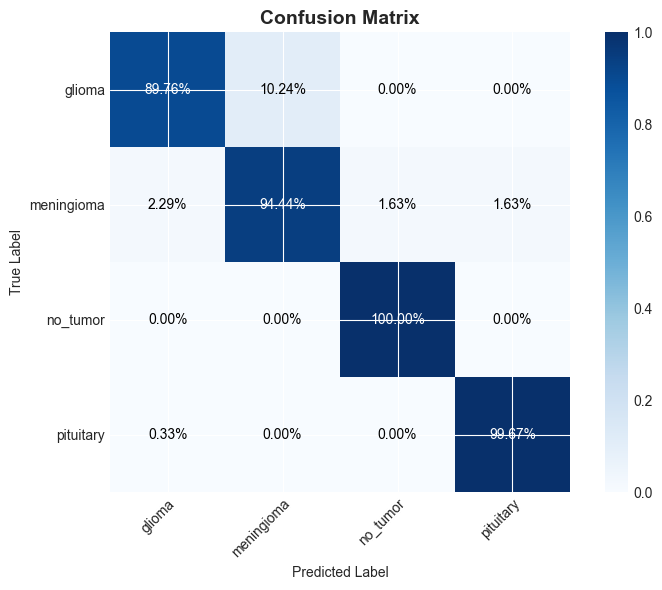

💾 Confusion matrix saved: ConvNeXt_confusion_matrix.png

╭───────────────────────────╮
│ 🔍 Evaluating ResNet152V2 │
╰───────────────────────────╯

✓ Model loaded: ResNet152V2_best_weights.keras

32/32 ━━━━━━━━━━━━━━━━━━━━ 171s 5s/step - accuracy: 0.9550 - auc_ovr: 0.9964 - loss: 0.1246 - overall_precision: 0.9560 - overall_recall: 0.9550

📊 Evaluation Results:
   accuracy: 95.50%
   auc_ovr: 99.64%
   loss: 0.1246
   overall_precision: 95.60%
   overall_recall: 95.50%
   sklearn_accuracy: 95.50%
   macro_precision: 95.59%
   macro_recall: 96.00%
   macro_f1: 95.78%
   weighted_f1: 95.47%

📋 Classification Report:
              precision    recall  f1-score   support

      glioma     0.9476    0.9252    0.9363       254
  meningioma     0.9400    0.9216    0.9307       306
    no_tumor     0.9655    1.0000    0.9825       140
   pituitary     0.9707    0.9933    0.9819       300

    accuracy                         0.9550      1000
   macro avg     0.9559    0.9600    0.9578      1000
weighted avg     0.9547    0.9550    0.9547      1000

📊 Confusion matrix saved to: c:\Users\USER\Desktop\AI-Assisted-Brain-Tumor-Localization-and-Classification-in-Medical-Imaging\logs\classifi

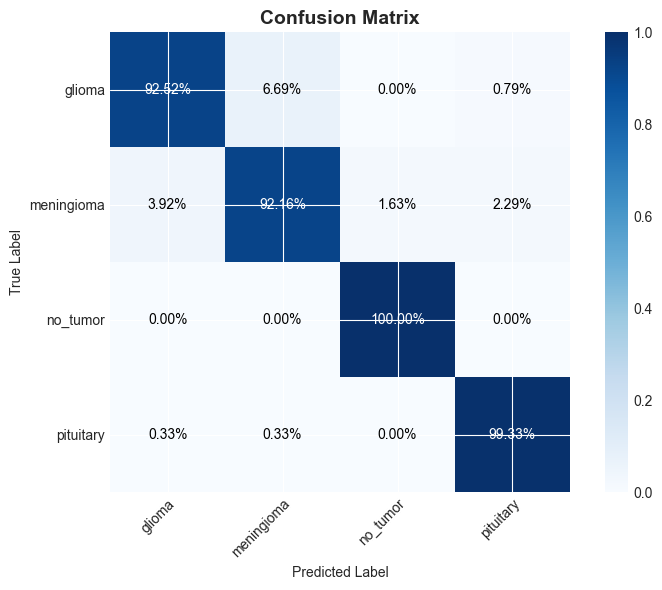

💾 Confusion matrix saved: ResNet152V2_confusion_matrix.png

╭───────────────────────────╮
│ 🔍 Evaluating DenseNet201 │
╰───────────────────────────╯

✓ Model loaded: DenseNet201_best_weights.keras

32/32 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.9660 - auc_ovr: 0.9945 - loss: 0.1283 - overall_precision: 0.9659 - overall_recall: 0.9630

📊 Evaluation Results:
   accuracy: 96.60%
   auc_ovr: 99.45%
   loss: 0.1283
   overall_precision: 96.59%
   overall_recall: 96.30%
   sklearn_accuracy: 96.60%
   macro_precision: 96.71%
   macro_recall: 96.94%
   macro_f1: 96.81%
   weighted_f1: 96.58%

📋 Classification Report:
              precision    recall  f1-score   support

      glioma     0.9713    0.9331    0.9518       254
  meningioma     0.9446    0.9477    0.9462       306
    no_tumor     0.9722    1.0000    0.9859       140
   pituitary     0.9803    0.9967    0.9884       300

    accuracy                         0.9660      1000
   macro avg     0.9671    0.9694    0.9681      1000
weighted avg     0.9660    0.9660    0.9658      1000

📊 Confusion matrix saved to: c:\Users\USER\Desktop\AI-Assisted-Brain-Tumor-Localization-and-Classification-in-Medical-Imaging\logs\classifi

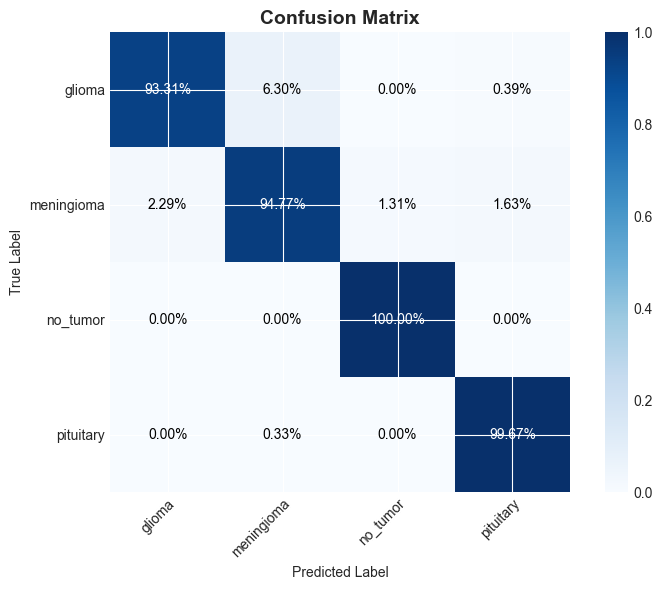

💾 Confusion matrix saved: DenseNet201_confusion_matrix.png

╭───────────────────────────────╮
│ 🔍 Evaluating EfficientNetV2S │
╰───────────────────────────────╯

✓ Model loaded: EfficientNetV2S_best_weights.keras

32/32 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.9540 - auc_ovr: 0.9957 - loss: 0.1317 - overall_precision: 0.9559 - overall_recall: 0.9530

📊 Evaluation Results:
   accuracy: 95.40%
   auc_ovr: 99.57%
   loss: 0.1317
   overall_precision: 95.59%
   overall_recall: 95.30%
   sklearn_accuracy: 95.40%
   macro_precision: 95.89%
   macro_recall: 95.80%
   macro_f1: 95.81%
   weighted_f1: 95.37%

📋 Classification Report:
              precision    recall  f1-score   support

      glioma     0.9620    0.8976    0.9287       254
  meningioma     0.9233    0.9444    0.9338       306
    no_tumor     0.9859    1.0000    0.9929       140
   pituitary     0.9643    0.9900    0.9770       300

    accuracy                         0.9540      1000
   macro avg     0.9589    0.9580    0.9581      1000
weighted avg     0.9542    0.9540    0.9537      1000

📊 Confusion matrix saved to: c:\Users\USER\Desktop\AI-Assisted-Brain-Tumor-Localization-and-Classification-in-Medical-Imaging\logs\classifi

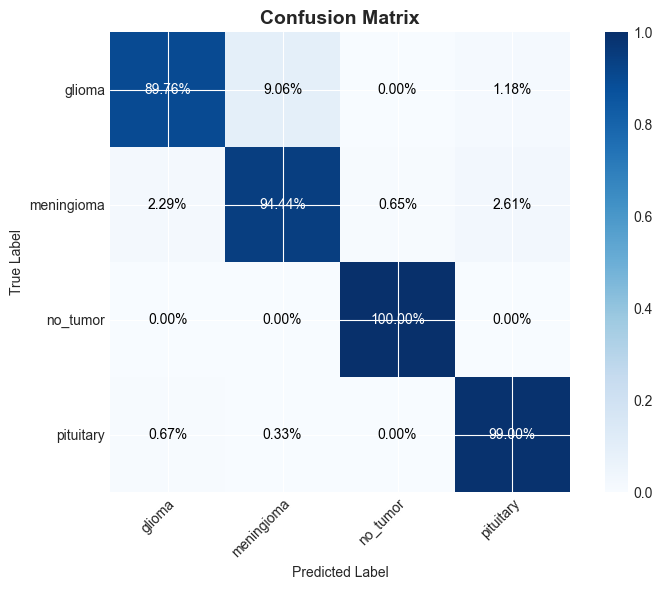

💾 Confusion matrix saved: EfficientNetV2S_confusion_matrix.png

╭─────────────────────╮
│ 🔍 Evaluating VGG16 │
╰─────────────────────╯

✓ Model loaded: VGG16_best_weights.keras

32/32 ━━━━━━━━━━━━━━━━━━━━ 273s 8s/step - accuracy: 0.9520 - auc_ovr: 0.9899 - loss: 0.1775 - overall_precision: 0.9530 - overall_recall: 0.9520

📊 Evaluation Results:
   accuracy: 95.20%
   auc_ovr: 98.99%
   loss: 0.1775
   overall_precision: 95.30%
   overall_recall: 95.20%
   sklearn_accuracy: 95.20%
   macro_precision: 95.51%
   macro_recall: 95.67%
   macro_f1: 95.56%
   weighted_f1: 95.17%

📋 Classification Report:
              precision    recall  f1-score   support

      glioma     0.9583    0.9055    0.9312       254
  meningioma     0.9223    0.9314    0.9268       306
    no_tumor     0.9722    1.0000    0.9859       140
   pituitary     0.9674    0.9900    0.9786       300

    accuracy                         0.9520      1000
   macro avg     0.9551    0.9567    0.9556      1000
weighted avg     0.9520    0.9520    0.9517      1000

📊 Confusion matrix saved to: c:\Users\USER\Desktop\AI-Assisted-Brain-Tumor-Localization-and-Classification-in-Medical-Imaging\logs\classifi

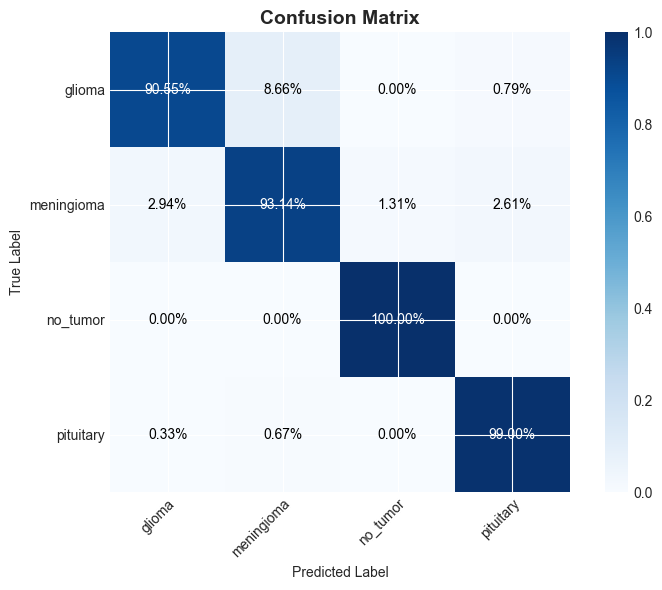

💾 Confusion matrix saved: VGG16_confusion_matrix.png

✓ All models evaluated!

In [9]:
results_data = []

# Evaluate models with progress bar
for name, info in tqdm(models_info.items(), desc="Evaluating models", unit="model"):
    console.print(Panel(f"[bold cyan]🔍 Evaluating {name}[/bold cyan]", expand=False))
    
    # Load model
    weights_path = PROJECT_ROOT / info['weights']
    if not weights_path.exists():
        console.print(f"[red]✗ Weights not found:[/red] {weights_path}")
        continue
    
    model = tf.keras.models.load_model(weights_path)
    console.print(f"[green]✓ Model loaded:[/green] {weights_path.name}")
    
    # Prepare dataset
    test_ds = make_dataset(
        test_df,
        model_name=info['model_name'],
        shuffle=False,
        batch_size=32,
    )
    
    # Create evaluator and evaluate
    evaluator = ClassificationEvaluator(model, test_ds)
    metrics = evaluator.evaluate(verbose=True)
    
    # Get per-class metrics
    per_class = evaluator.get_per_class_metrics()
    
    # Calculate standard deviations for error bars
    precisions = [m['precision'] for m in per_class.values()]
    recalls = [m['recall'] for m in per_class.values()]
    f1s = [m['f1'] for m in per_class.values()]
    
    precision_std = np.std(precisions)
    recall_std = np.std(recalls)
    f1_std = np.std(f1s)
    
    # Store results
    results_data.append({
        'Model': name,
        'Accuracy': metrics['sklearn_accuracy'],
        'Precision': metrics['macro_precision'],
        'Recall': metrics['macro_recall'],
        'F1': metrics['macro_f1'],
        'AUC': metrics.get('auc_ovr', 0.0),
        'Precision_Std': precision_std,
        'Recall_Std': recall_std,
        'F1_Std': f1_std
    })
    
    # Print classification report
    evaluator.print_classification_report()
    
    # Plot confusion matrix
    cm_path = PROJECT_ROOT / f'logs/classification/{name}_confusion_matrix.png'
    evaluator.plot_confusion_matrix(normalize=True, save_path=str(cm_path))
    console.print(f"[green]💾 Confusion matrix saved:[/green] {cm_path.name}\n")

console.print("[bold green]✓ All models evaluated![/bold green]")

## 6. Results Summary

In [10]:
# Create results DataFrame
results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('Accuracy', ascending=False)

# Create Rich table
table = Table(title="📊 Test Set Results Summary", show_header=True, header_style="bold magenta")
table.add_column("Model", style="cyan", no_wrap=True)
table.add_column("Accuracy", justify="right", style="green")
table.add_column("Precision", justify="right", style="yellow")
table.add_column("Recall", justify="right", style="blue")
table.add_column("F1", justify="right", style="magenta")
table.add_column("AUC", justify="right", style="red")

for _, row in results_df.iterrows():
    table.add_row(
        row['Model'],
        f"{row['Accuracy']*100:.2f}%",
        f"{row['Precision']*100:.2f}%",
        f"{row['Recall']*100:.2f}%",
        f"{row['F1']*100:.2f}%",
        f"{row['AUC']*100:.2f}%"
    )

console.print(table)

# Display best model
best_model = results_df.iloc[0]['Model']
best_acc = results_df.iloc[0]['Accuracy']*100
console.print(f"\n[bold green]🏆 Best Performing Model:[/bold green] [bold cyan]{best_model}[/bold cyan] with [bold yellow]{best_acc:.2f}%[/bold yellow] accuracy")

# Display as styled table
results_df.style.highlight_max(axis=0, props='font-weight:bold;color:green')

                     📊 Test Set Results Summary                     
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Model           ┃ Accuracy ┃ Precision ┃ Recall ┃     F1 ┃    AUC ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ DenseNet201     │   96.60% │    96.71% │ 96.94% │ 96.81% │ 99.45% │
│ ConvNeXt        │   95.60% │    95.82% │ 95.97% │ 95.85% │ 99.63% │
│ ResNet152V2     │   95.50% │    95.59% │ 96.00% │ 95.78% │ 99.64% │
│ EfficientNetV2S │   95.40% │    95.89% │ 95.80% │ 95.81% │ 99.57% │
│ VGG16           │   95.20% │    95.51% │ 95.67% │ 95.56% │ 98.99% │
└─────────────────┴──────────┴───────────┴────────┴────────┴────────┘

🏆 Best Performing Model: DenseNet201 with 96.60% accuracy

,Model,Accuracy,Precision,Recall,F1,AUC,Precision_Std,Recall_Std,F1_Std
2,DenseNet201,0.966000,0.967122,0.969362,0.968080,0.994456,0.013454,0.029453,0.019217
0,ConvNeXt,0.956000,0.958158,0.959687,0.958473,0.996291,0.024589,0.042057,0.027918
1,ResNet152V2,0.955000,0.955945,0.960025,0.957821,0.996430,0.012580,0.036740,0.024427
3,EfficientNetV2S,0.954000,0.958887,0.958021,0.958091,0.995725,0.022552,0.040667,0.027493
4,VGG16,0.952000,0.955078,0.956721,0.955626,0.989871,0.019554,0.039514,0.026794


### 6.1 Metrics Visualization

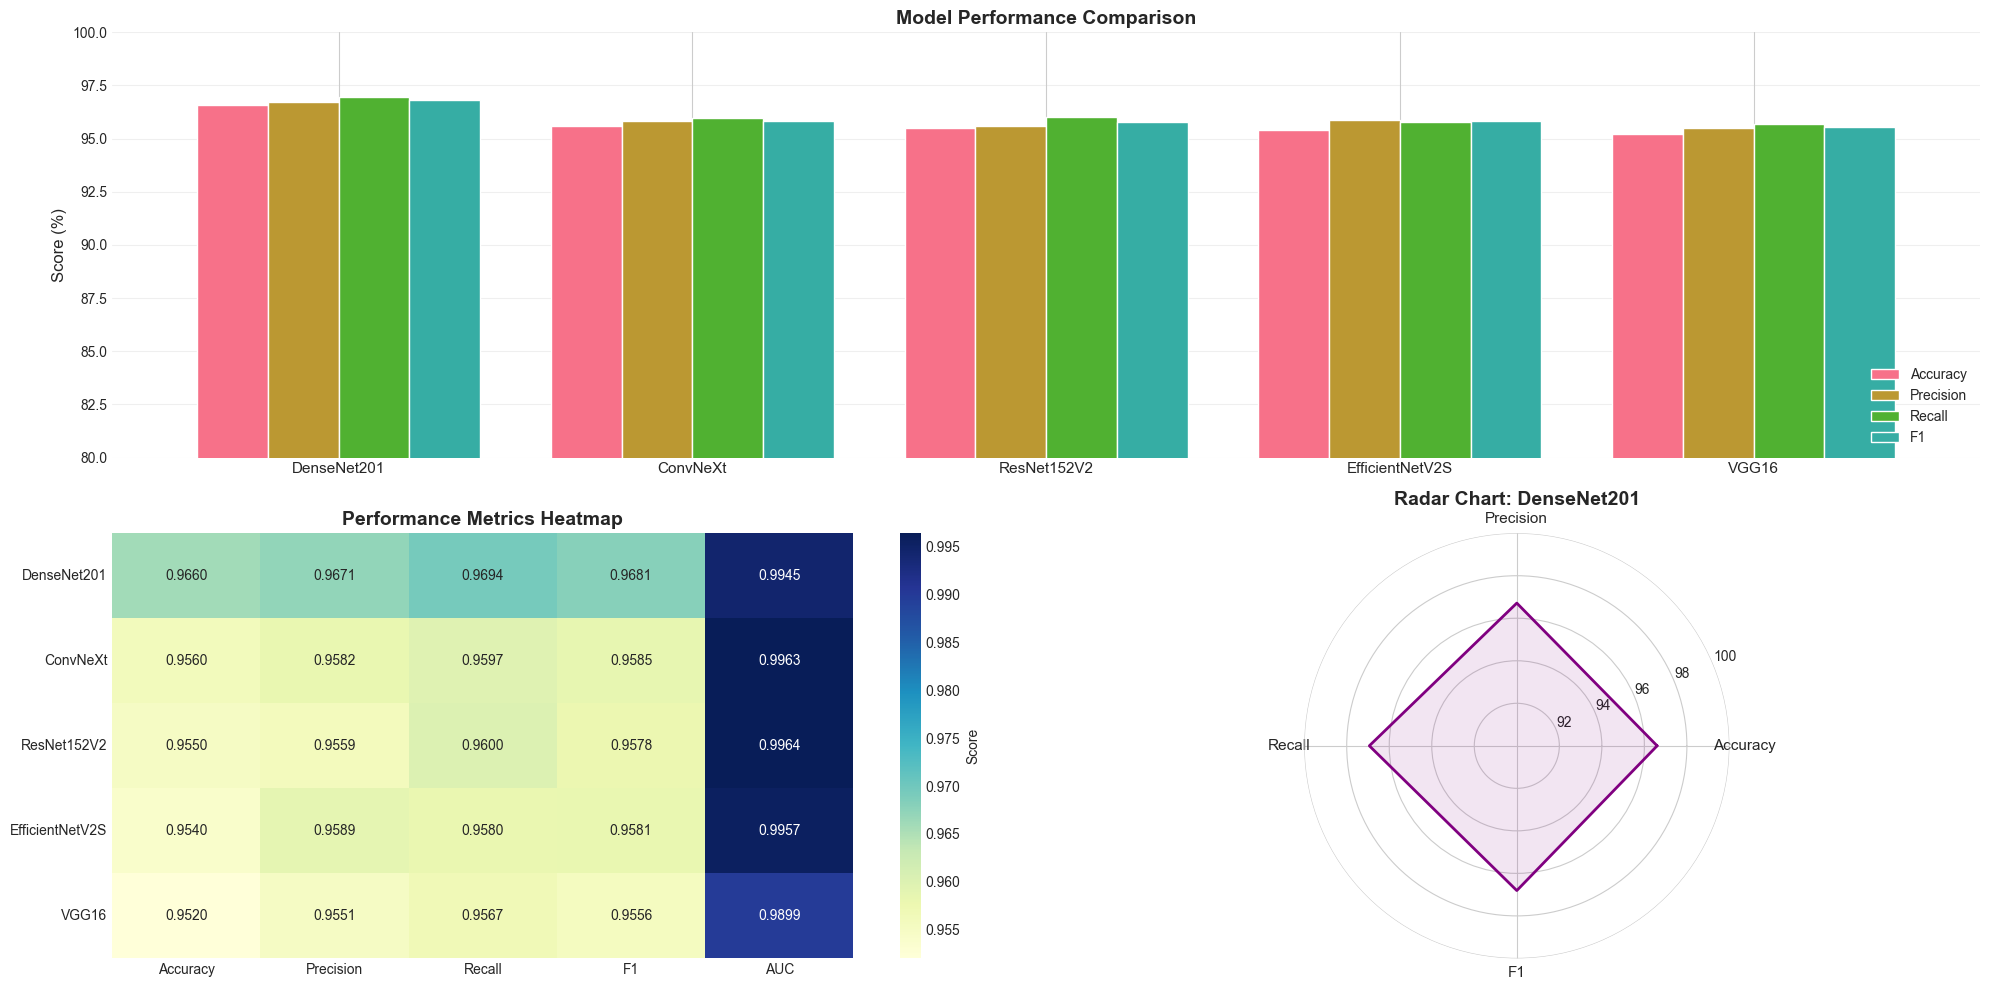

In [18]:
# Updated Visualization Code
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Create figure with grid layout
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 2)

# 1. Bar Chart with Error Bars
ax1 = fig.add_subplot(gs[0, :])

# Prepare data for plotting
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(results_df))
width = 0.2
models = results_df['Model'].tolist()

# Plot bars
for i, metric in enumerate(metrics_to_plot):
    means = results_df[metric] * 100
    offset = width * i
    rects = ax1.bar(x + offset, means, width, label=metric,  capsize=5)

ax1.set_ylabel('Score (%)', fontsize=12)
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(models, fontsize=11)
ax1.legend(loc='lower right')
ax1.set_ylim([80, 100])
ax1.grid(True, axis='y', alpha=0.3)

# 2. Heatmap
ax2 = fig.add_subplot(gs[1, 0])
heatmap_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
heatmap_data = results_df[heatmap_metrics].set_index(results_df['Model'])
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax2, cbar_kws={'label': 'Score'})
ax2.set_title('Performance Metrics Heatmap', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

# 3. Radar Chart for Best Model
ax3 = fig.add_subplot(gs[1, 1], projection='polar')

# Data for best model
best_model_idx = 0 # Assumed sorted by Accuracy descending
best_model_name = results_df.iloc[best_model_idx]['Model']
radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
values = [results_df.iloc[best_model_idx][m] * 100 for m in radar_metrics]
values += values[:1] # Close the loop

# Angles
angles = [n / float(len(radar_metrics)) * 2 * np.pi for n in range(len(radar_metrics))]
angles += angles[:1]

# Plot
ax3.plot(angles, values, linewidth=2, linestyle='solid', label=best_model_name, color='purple')
ax3.fill(angles, values, 'purple', alpha=0.1)

# Formatting
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(radar_metrics, size=11)
ax3.set_ylim(90, 100)
ax3.set_title(f'Radar Chart: {best_model_name}', fontsize=14, fontweight='bold', pad=20)
ax3.grid(True)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'logs/classification/comprehensive_evaluation_results.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Update README

In [12]:
# Read current README
readme_path = PROJECT_ROOT / 'README.md'
with open(readme_path, 'r', encoding='utf-8') as f:
    readme_content = f.read()

# Create results table in markdown
results_table = "\n## 📈 Results\n\n"
results_table += "Test set performance on 1,000 T1-weighted MRI slices from the BRISC2025 dataset:\n\n"
results_table += "| Model | Accuracy | Precision | Recall | F1 Score | AUC |\n"
results_table += "|-------|----------|-----------|--------|----------|-----|\n"

for _, row in results_df.iterrows():
    results_table += f"| **{row['Model']}** | "
    results_table += f"{row['Accuracy']*100:.2f}% | "
    results_table += f"{row['Precision']*100:.2f}% | "
    results_table += f"{row['Recall']*100:.2f}% | "
    results_table += f"{row['F1']*100:.2f}% | "
    results_table += f"{row['AUC']*100:.2f}% |\n"

best_model = results_df.iloc[0]['Model']
best_acc = results_df.iloc[0]['Accuracy']*100
results_table += f"\n**Best Performing Model:** {best_model} with {best_acc:.2f}% accuracy\n\n"
results_table += "*All models use transfer learning with frozen backbones and custom classification heads.*\n"

# Find and replace the results section
import re
pattern = r'## 📈 Results.*?(?=##|$)'
updated_readme = re.sub(pattern, results_table, readme_content, flags=re.DOTALL)

# Write updated README
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(updated_readme)

console.print(Panel("[bold green]✓ README.md updated with test results![/bold green]", expand=False))
console.print("\n[bold cyan]Preview of results section:[/bold cyan]")
console.print(results_table)

╭────────────────────────────────────────╮
│ ✓ README.md updated with test results! │
╰────────────────────────────────────────╯

Preview of results section:

## 📈 Results

Test set performance on 1,000 T1-weighted MRI slices from the BRISC2025 dataset:

| Model | Accuracy | Precision | Recall | F1 Score | AUC |
|-------|----------|-----------|--------|----------|-----|
| **DenseNet201** | 96.60% | 96.71% | 96.94% | 96.81% | 99.45% |
| **ConvNeXt** | 95.60% | 95.82% | 95.97% | 95.85% | 99.63% |
| **ResNet152V2** | 95.50% | 95.59% | 96.00% | 95.78% | 99.64% |
| **EfficientNetV2S** | 95.40% | 95.89% | 95.80% | 95.81% | 99.57% |
| **VGG16** | 95.20% | 95.51% | 95.67% | 95.56% | 98.99% |

**Best Performing Model:** DenseNet201 with 96.60% accuracy

*All models use transfer learning with frozen backbones and custom classification heads.*

## Summary

✅ **Completed Tasks:**
1. Loaded training logs for all 5 models
2. Visualized training curves (loss, accuracy, recall, AUC)
3. Evaluated all models on test dataset
4. Generated confusion matrices
5. Created performance comparison visualizations


**Generated Artifacts:**
- Training curve plots in `logs/classification/`
- Confusion matrices for each model
- Test results comparison chart

